In [1]:
# DATA VISUALISATION — ICMM Global Mining Dataset v1.5 (Latin America)
#
# Goal: show where large-scale mining is in Latin America and the Caribbean, which minerals each country mines, and how reliable the data is, using only the clean ICMM tables made by icmm_mining_sites_cleaning.ipynb.
#
# Project question: Do resource-rich countries in Latin America see more killings of environmental defenders?
# This notebook answers the first half only: which countries are resource-rich in large-scale mining. It uses the ICMM data only (no other dataset).
#
# File — What it contains (both in github.com/len-chou/TeamTokio---Week-3-Project-)
# icmm_sites_latam.csv — one row per site (709 sites): name, country, coordinates, type of site, minerals, confidence. Used by charts 1, 2, 3, 5 and 6.
# icmm_site_commodities.csv — one row per site and mineral (1,616 rows). Used by chart 4 (heatmap).
#
# The six charts
# 1. Map of all sites, coloured by mineral group, with the country names
# 2. Number of sites per country, split by mineral group (all sites vs reliable sites only)
# 3. Gold sites and critical-mineral sites per country
# 4. Country × mineral heatmap
# 5. Confidence of the data per country
# 6. Type of site (mine, smelter / refinery, …)
#
# Read every chart with this in mind:
# - The numbers are counts of sites, not production: a giant copper mine and a small silver mine each count as one site.
# - "Critical mineral" = a mineral in the IEA Critical Minerals Dataset 2026 (see the cleaning notebook, step 3E).
# - A quarter of the sites have "Very Low" confidence; chart 5 shows where.
#
# Every chart is also saved as a PNG file in the figures/ folder, for slides or the report.

In [2]:
# 1) Importing the libraries
#
# - pandas (pd) — to read the clean tables and count sites.
# - matplotlib (plt) — to draw the charts; patheffects (pe) — to draw a thin white outline around the country names on the map, so they stay readable over the dots.
# - seaborn (sns) — only for the heatmap (chart 4).
# - Path — to create the figures/ folder.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

In [4]:
# 2) Load the clean data
#
# What: read the two clean tables made by the cleaning notebook, straight from our GitHub repo.
#
# Why: reading from the repo means everyone in the team makes the charts from exactly the same files, with no local copies.
#
# Output: the size (rows, columns) of each table.

In [5]:
repo = "https://raw.githubusercontent.com/len-chou/TeamTokio---Week-3-Project-/refs/heads/main/"
FIG_DIR = Path("figures")          # the charts are saved here, next to this notebook
FIG_DIR.mkdir(exist_ok=True)

sites = pd.read_csv(repo + "icmm_sites_latam.csv")
minerals = pd.read_csv(repo + "icmm_site_commodities.csv")

print("Sites:", sites.shape)
print("Site × mineral rows:", minerals.shape)

Sites: (709, 33)
Site × mineral rows: (1616, 10)


In [6]:
# 3) Chart style and colours
#
# What: one set of colours and one style for every chart, so the charts look like one family.
#
# How:
# - Three groups of minerals, each with its own colour, always the same in every chart:
#   critical mineral = blue, gold = orange, other minerals = green.
#   "Other minerals" joins two groups of the cleaning notebook: "iron, steel & coal" and "other" (bauxite, tin, antimony, barium, phosphate, potash…). Three colours are easier to tell apart on a map than four.
# - The colours were checked to stay distinguishable for colour-blind readers, and every chart also has a legend or labels, so colour is never the only clue.
# - Confidence (chart 5) is an ordered scale, so it uses one colour from light (Very Low) to dark (High).
# - Grid lines are light grey, thin and drawn behind the bars, so the data stands out; the top and right frame lines are removed.
#
# Output: nothing is printed.

In [7]:
GROUP_COLOURS = {"critical mineral": "#2a78d6", "gold": "#eb6834", "other minerals": "#1baf7a"}
GROUP_ORDER = list(GROUP_COLOURS)
CONF_COLOURS = {"Very Low": "#86b6ef", "Moderate": "#2a78d6", "High": "#104281"}
TEXT, TEXT_SOFT, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": TEXT_SOFT, "axes.labelcolor": TEXT_SOFT, "axes.titlecolor": TEXT,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": TEXT_SOFT, "ytick.color": TEXT_SOFT, "font.size": 10,
    "legend.frameon": False,
})

# the three mineral groups used in every chart
sites["group"] = sites["mineral_group"].replace({"iron, steel & coal": "other minerals", "other": "other minerals"})

In [8]:
# 4) Chart 1 — Map of all mining sites, with the country names
#
# What: every site is a dot, placed by its longitude (left–right) and latitude (up–down), coloured by its mineral group.
# The name of every country of the project (Mexico, Central America, the Caribbean and South America) is written on the map.
#
# Why: it shows at a glance where large-scale mining is concentrated, and in which country.
#
# How:
# - plt.scatter draws one dot per site; we draw the three groups one after the other so each gets its colour and a legend entry with its number of sites.
# - COUNTRY_LABELS gives, for each country, where to write its name (longitude, latitude):
#   - large countries (Mexico, Brazil, Peru…): the name in capitals, inside the country;
#   - small or narrow countries (Central America, Caribbean islands, Chile, Ecuador, Uruguay, Guyana, Suriname): the name next to the country, in the sea,
#     with a thin line pointing to the country, so the names do not cover each other or the dots.
#   The positions were chosen by hand (approximate centre of each country); change a number to move a name.
# - A thin white outline around each name (path_effects) keeps it readable when it sits on top of dots.
# - set_aspect("equal") keeps one degree of latitude and one degree of longitude the same size, so the shape of Latin America is not stretched.
# - There are no country borders (that would need an extra mapping library); the interactive map in the next cell has borders and the names too.
#
# How to read it: dots cluster along the Andes (Chile, Peru, Bolivia), in south-east Brazil, and in northern and central Mexico. Blue (critical minerals, mostly copper, silver and zinc) dominates the Andes and Mexico; green (iron ore, coal, bauxite, tin) dominates Brazil.
# Some named countries have no dot: ICMM lists no site in Paraguay, Uruguay, Costa Rica, El Salvador, Belize or Haiti.
#
# Output: the map, saved as figures/1_map_sites.png.

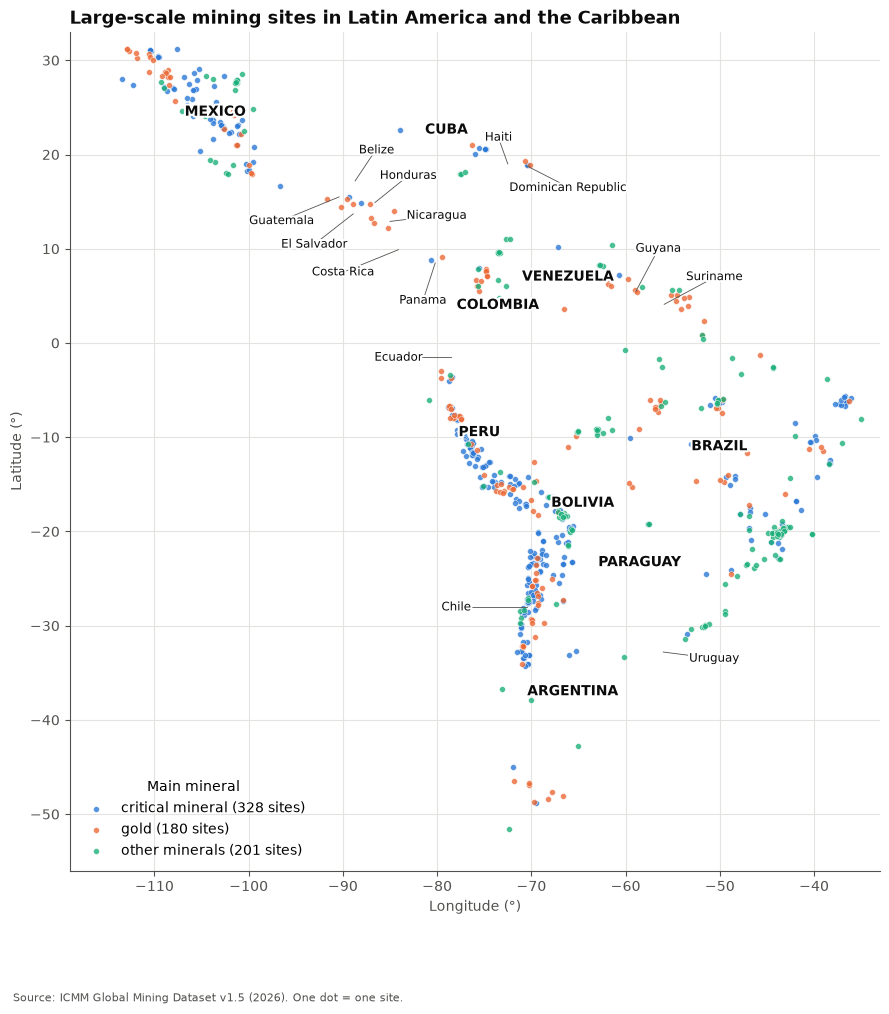

In [9]:
# where to write each country name: label position (lon, lat), and for small countries the point the leader line goes to
COUNTRY_LABELS = {
    # large countries: name written inside the country
    "Mexico": (-103.5, 24.5, None), "Colombia": (-73.5, 4.0, None), "Venezuela": (-66.0, 7.0, None),
    "Peru": (-75.5, -9.5, None), "Brazil": (-50.0, -11.0, None), "Bolivia": (-64.5, -17.0, None),
    "Paraguay": (-58.5, -23.3, None), "Argentina": (-65.5, -37.0, None), "Cuba": (-79.0, 22.6, None),
    # small or narrow countries: name written next to them, with a thin line
    "Chile": (-78.0, -28.0, (-70.5, -28.0)), "Ecuador": (-84.0, -1.5, (-78.5, -1.5)), "Uruguay": (-50.5, -33.5, (-56.0, -32.8)),
    "Guyana": (-56.5, 10.0, (-58.9, 5.5)), "Suriname": (-50.5, 7.0, (-55.9, 4.1)),
    "Guatemala": (-96.5, 13.0, (-90.4, 15.5)), "El Salvador": (-93.0, 10.5, (-88.9, 13.7)),
    "Honduras": (-83.0, 17.8, (-86.6, 14.9)), "Belize": (-86.5, 20.5, (-88.7, 17.2)),
    "Nicaragua": (-80.0, 13.5, (-85.0, 12.9)), "Costa Rica": (-90.0, 7.5, (-84.1, 9.9)), "Panama": (-81.5, 4.5, (-80.2, 8.5)),
    "Haiti": (-73.5, 21.8, (-72.5, 19.0)), "Dominican Republic": (-66.0, 16.5, (-70.5, 18.8)),
}
halo = [pe.withStroke(linewidth=3, foreground="white")]      # white outline, so names stay readable over the dots

fig, ax = plt.subplots(figsize=(9, 11))
for grp in GROUP_ORDER:
    part = sites[sites["group"] == grp]
    ax.scatter(part["lon"], part["lat"], s=18, color=GROUP_COLOURS[grp], alpha=0.8,
               edgecolor="white", linewidth=0.4, label=f"{grp} ({len(part)} sites)")

for country, (x, y, point) in COUNTRY_LABELS.items():
    small = point is not None
    if small:
        ax.plot([x, point[0]], [y, point[1]], color=TEXT_SOFT, linewidth=0.6, zorder=4)
    name = country.upper() if not small else country
    ax.text(x, y, name, ha="center", va="center", zorder=5, fontsize=8.5 if small else 10,
            fontweight="normal" if small else "bold", color=TEXT, path_effects=halo)

ax.set_aspect("equal")
ax.set_xlim(-119, -33)
ax.set_ylim(-56, 33)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title("Large-scale mining sites in Latin America and the Caribbean")
ax.legend(title="Main mineral", loc="lower left")
fig.text(0.02, 0.01, "Source: ICMM Global Mining Dataset v1.5 (2026). One dot = one site.",
         color=TEXT_SOFT, fontsize=8)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.savefig(FIG_DIR / "1_map_sites.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# 4b) Optional — interactive map with country borders and names
#
# What: the same map with country borders and the country names; move the mouse over a dot to see the site name, country, minerals and confidence. You can zoom in.
#
# How:
# - it uses the plotly library, which draws the borders by itself;
# - the names come from COUNTRY_LABELS (previous cell): large countries in capitals at their label position, small countries in smaller text on the country itself
#   (here the borders show which country is which, so no pointing lines are needed); the names are not clickable (hoverinfo="skip");
# - if plotly is not installed, the cell prints how to install it (pip install plotly) and does nothing else.
#
# Output: the interactive map (only if plotly is installed).

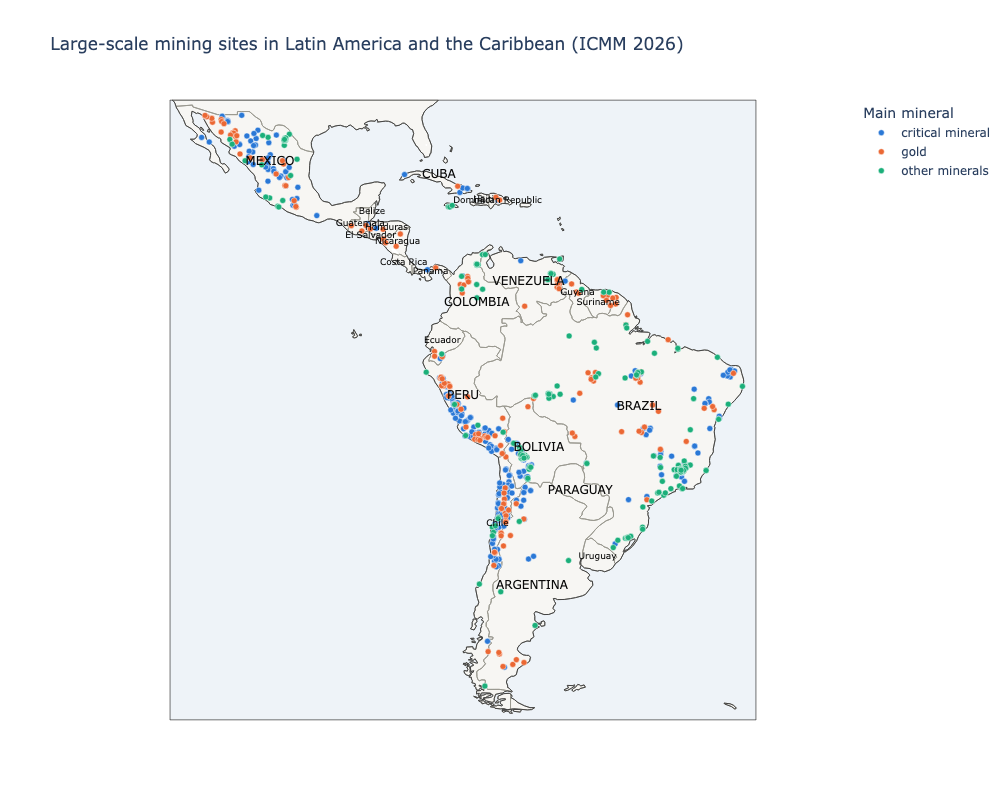

In [11]:
try:
    import plotly.express as px
    import plotly.graph_objects as go
    fig = px.scatter_geo(
        sites, lat="lat", lon="lon", color="group",
        color_discrete_map=GROUP_COLOURS, category_orders={"group": GROUP_ORDER},
        hover_name="site_name",
        hover_data={"country": True, "minerals_all": True, "asset_type": True,
                    "confidence_factor": True, "lat": False, "lon": False, "group": False},
        title="Large-scale mining sites in Latin America and the Caribbean (ICMM 2026)",
    )
    fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color="white")))

    # country names: large countries at their label position, small ones on the country itself (smaller text)
    names = pd.DataFrame([(c, *(p if p else (x, y)), p is not None) for c, (x, y, p) in COUNTRY_LABELS.items()],
                         columns=["country", "lon", "lat", "small"])
    for small, part in names.groupby("small"):
        fig.add_trace(go.Scattergeo(
            lon=part["lon"], lat=part["lat"], mode="text",
            text=part["country"] if small else part["country"].str.upper(),
            textfont=dict(size=9 if small else 12, color="#0b0b0b"),
            hoverinfo="skip", showlegend=False,
        ))

    fig.update_geos(scope="world", lataxis_range=[-56, 33], lonaxis_range=[-118, -33],
                    showcountries=True, countrycolor="#9a9990", showland=True, landcolor="#f7f6f3",
                    showocean=True, oceancolor="#eef3f8")
    fig.update_layout(height=800, legend_title_text="Main mineral")
    fig.show()
except ImportError:
    print("plotly is not installed. To get the interactive map, run: pip install plotly — then run this cell again.")

In [12]:
# 5) Chart 2 — Number of sites per country
#
# What: one horizontal bar per country, split by mineral group. Left: all sites. Right: reliable sites only (High and Moderate confidence).
#
# Why: this is the simplest measure of how "resource-rich" each country is in large-scale mining. Showing the reliable-only version next to it shows which countries' counts depend on low-confidence sites.
#
# How:
# - pd.crosstab counts the sites per country and group;
# - countries are sorted by their total number of sites (all sites), and both panels keep the same order and the same scale, so they can be compared bar by bar;
# - plot(kind="barh", stacked=True) stacks the three groups in one bar; the white edge leaves a small gap between the parts.
#
# How to read it: Brazil (196 sites), Peru (129), Mexico (109) and Chile (102) have far more sites than every other country. Peru and Chile are mostly critical minerals (copper, zinc, silver); Brazil is mostly other minerals (iron ore, coal, bauxite, tin). With reliable sites only, Bolivia drops from 54 to 17 sites: most of its sites are "Very Low" confidence.
#
# Output: the two-panel chart, saved as figures/2_sites_per_country.png.

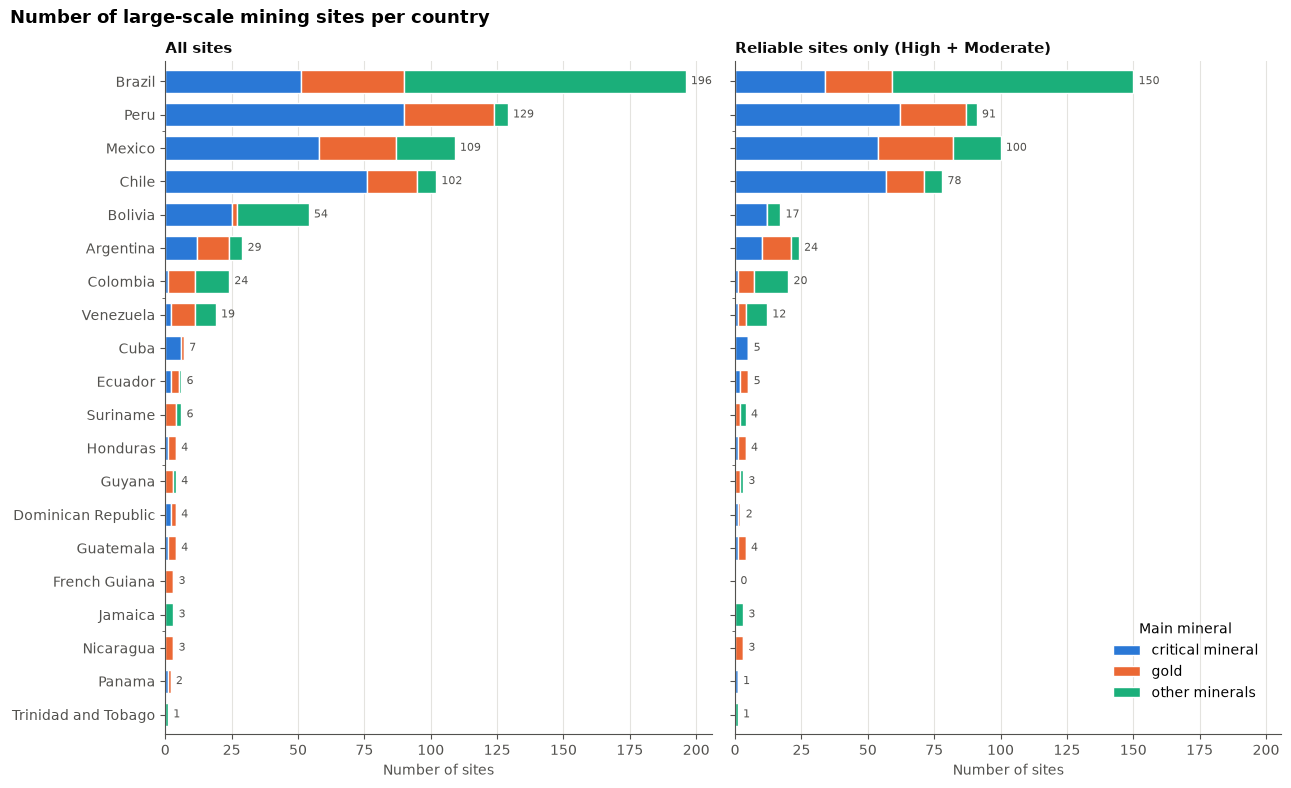

In [13]:
counts_all = pd.crosstab(sites["country"], sites["group"])[GROUP_ORDER]
counts_rel = pd.crosstab(sites.loc[sites["reliable"], "country"], sites.loc[sites["reliable"], "group"])
counts_rel = counts_rel.reindex(index=counts_all.index, columns=GROUP_ORDER, fill_value=0)

order = counts_all.sum(axis=1).sort_values().index          # smallest at the bottom, largest at the top
fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)
for ax, data, title in [(axes[0], counts_all, "All sites"), (axes[1], counts_rel, "Reliable sites only (High + Moderate)")]:
    data.loc[order].plot(kind="barh", stacked=True, ax=ax, width=0.7,
                         color=[GROUP_COLOURS[g] for g in GROUP_ORDER], edgecolor="white", linewidth=1)
    for y, total in enumerate(data.loc[order].sum(axis=1)):
        ax.text(total + 2, y, str(total), va="center", fontsize=8, color=TEXT_SOFT)   # total at the end of each bar
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Number of sites")
    ax.set_ylabel("")
    ax.grid(axis="y", visible=False)
    ax.legend().remove()
axes[1].set_xlim(axes[0].get_xlim())                          # same scale in both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Main mineral", loc="lower right", bbox_to_anchor=(0.98, 0.1))
fig.suptitle("Number of large-scale mining sites per country", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "2_sites_per_country.png", dpi=200)
plt.show()

In [14]:
# 6) Chart 3 — Gold sites and critical-mineral sites per country
#
# What: two bars per country: the number of sites that produce gold, and the number of sites that produce at least one critical mineral.
#
# Why: the project looks at gold and critical minerals together; this shows which countries matter for each.
#
# How:
# - has_gold and has_critical (from the cleaning notebook) are True/False for each site; .sum() counts the True values per country.
# - These look at all the minerals of a site, not only the main one. So a copper mine that also produces gold counts in both bars, and the two bars of a country do not add up to its number of sites.
# - Only the 12 countries with the most sites are shown; the others have 4 sites or fewer.
#
# How to read it: Peru has the most sites in both (118 critical, 78 gold), followed by Chile and Mexico for critical minerals and by Mexico for gold. In Colombia, Venezuela, Ecuador and Suriname, gold sites outnumber critical-mineral sites.
#
# Output: the grouped bar chart, saved as figures/3_gold_vs_critical.png.

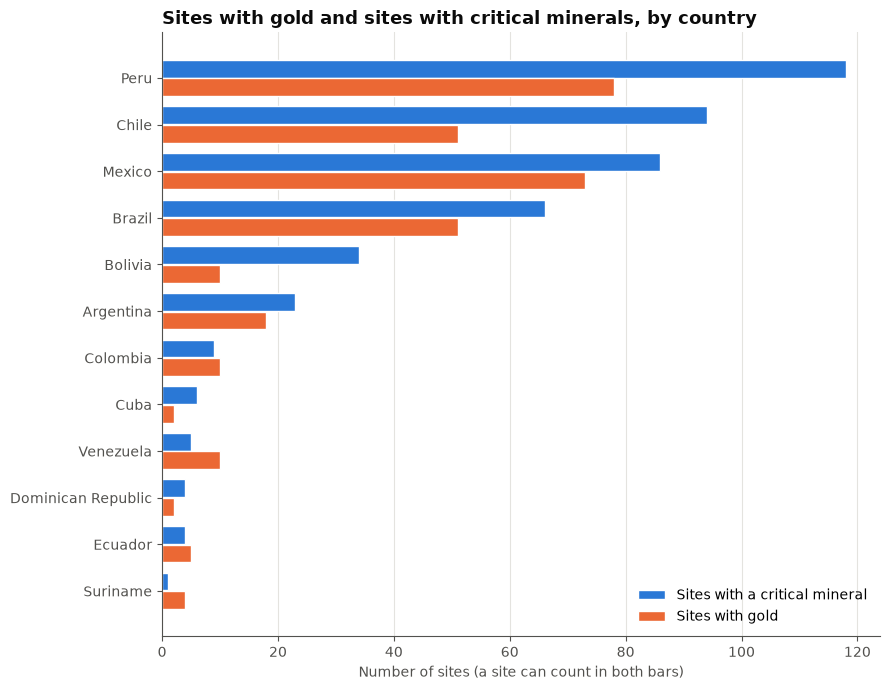

In [15]:
gc = sites.groupby("country")[["has_critical", "has_gold"]].sum()
gc = gc.loc[sites["country"].value_counts().index[:12]].sort_values("has_critical")   # 12 countries with most sites

fig, ax = plt.subplots(figsize=(9, 7))
y = range(len(gc))
ax.barh([i + 0.2 for i in y], gc["has_critical"], height=0.38, color=GROUP_COLOURS["critical mineral"],
        edgecolor="white", label="Sites with a critical mineral")
ax.barh([i - 0.2 for i in y], gc["has_gold"], height=0.38, color=GROUP_COLOURS["gold"],
        edgecolor="white", label="Sites with gold")
ax.set_yticks(list(y))
ax.set_yticklabels(gc.index)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Number of sites (a site can count in both bars)")
ax.set_title("Sites with gold and sites with critical minerals, by country")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "3_gold_vs_critical.png", dpi=200)
plt.show()

In [16]:
# 7) Chart 4 — Country × mineral heatmap
#
# What: a grid with countries down the side and minerals across the top; each cell shows how many sites in that country produce that mineral. Darker blue = more sites.
#
# Why: it shows the mining "profile" of each country in one picture.
#
# How:
# - We use the site × mineral table, so a mineral counts even when it is not the site's main mineral.
# - pd.crosstab counts sites per country and mineral; we keep the 12 most common minerals and the countries with at least 5 sites.
# - sns.heatmap colours each cell with one blue scale (light = few, dark = many) and writes the number in the cell; empty cells (0) stay white.
#
# How to read it: Chile stands out for copper and molybdenum; Peru for silver, gold, copper, zinc and lead; Mexico for silver, gold, zinc and copper; Bolivia for tin, zinc and silver; Brazil for gold, iron ore and tin. Lithium is not among the 12 minerals shown: only 11 sites in the whole list have lithium as their main mineral (Argentina, Chile, Brazil, Bolivia).
#
# Output: the heatmap, saved as figures/4_country_mineral_heatmap.png.

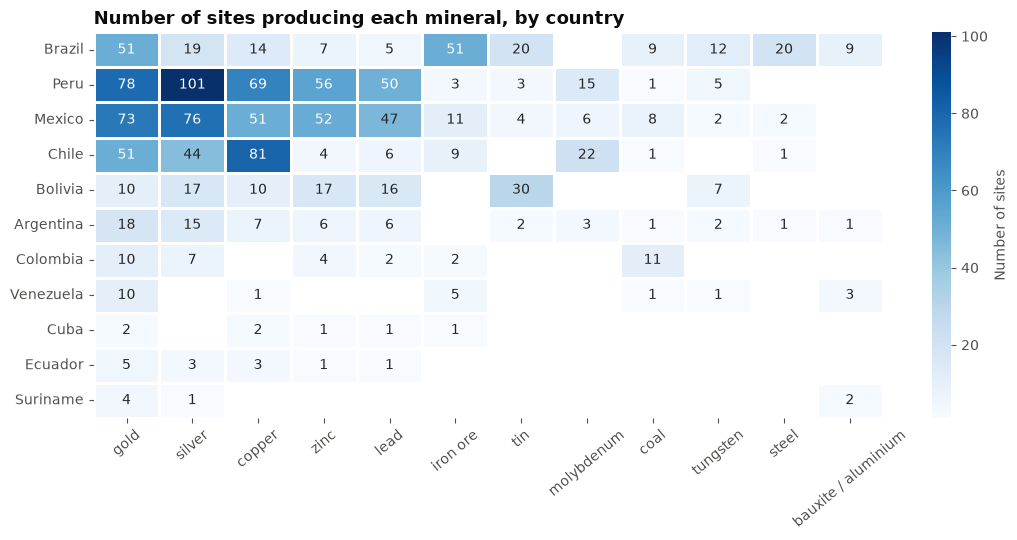

In [17]:
top_minerals = minerals["mineral"].value_counts().head(12).index
main_countries = sites["country"].value_counts()
main_countries = main_countries[main_countries >= 5].index

grid = pd.crosstab(minerals["country"], minerals["mineral"]).loc[main_countries, top_minerals]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(grid, annot=True, fmt="d", cmap="Blues", mask=grid.eq(0), linewidths=1, linecolor="white",
            cbar_kws={"label": "Number of sites"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)                                    # no grid lines across the heatmap
ax.set_title("Number of sites producing each mineral, by country")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.savefig(FIG_DIR / "4_country_mineral_heatmap.png", dpi=200)
plt.show()

In [18]:
# 8) Chart 5 — How reliable is the data in each country?
#
# What: one bar per country that always reaches 100 %, split into the share of sites with High, Moderate and Very Low confidence.
#
# Why: ICMM rates how sure it is about each site (explained in the cleaning notebook, step 3F). If a country has many "Very Low" sites, its count in chart 2 is less certain.
#
# How:
# - pd.crosstab(..., normalize="index") gives the share of each confidence level per country (each row sums to 1), multiplied by 100 for percent;
# - the colours go from light (Very Low) to dark (High), because confidence is an ordered scale;
# - only countries with at least 5 sites are shown, and the number of sites is written next to each country name.
#
# How to read it: Bolivia has by far the largest share of "Very Low" sites (69 %); Mexico has the smallest (8 %). The other countries are between 17 % and 37 % "Very Low".
#
# Output: the 100 % stacked bar chart, saved as figures/5_confidence_by_country.png.

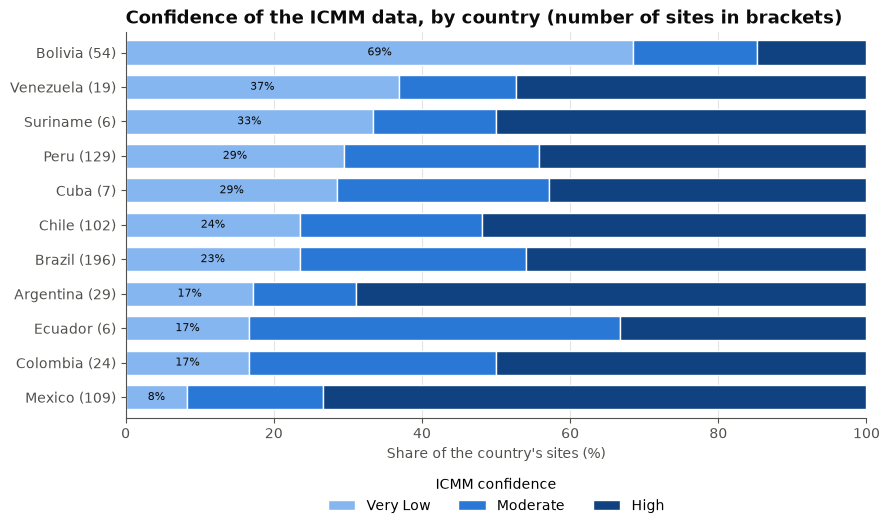

In [19]:
conf_levels = ["Very Low", "Moderate", "High"]
share = pd.crosstab(sites["country"], sites["confidence_factor"], normalize="index")[conf_levels] * 100
share = share.loc[main_countries].sort_values("Very Low")
n_sites = sites["country"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5.5))
share.plot(kind="barh", stacked=True, ax=ax, width=0.7, color=[CONF_COLOURS[c] for c in conf_levels],
           edgecolor="white", linewidth=1)
ax.set_yticklabels([f"{c} ({n_sites[c]})" for c in share.index])
for y, v in enumerate(share["Very Low"]):
    ax.text(v / 2, y, f"{v:.0f}%", va="center", ha="center", fontsize=8, color=TEXT)   # share of Very Low
ax.set_xlim(0, 100)
ax.set_xlabel("Share of the country's sites (%)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.set_title("Confidence of the ICMM data, by country (number of sites in brackets)")
ax.legend(title="ICMM confidence", loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=3)
plt.tight_layout()
plt.savefig(FIG_DIR / "5_confidence_by_country.png", dpi=200)
plt.show()

In [20]:
# 9) Chart 6 — Type of site
#
# What: the number of sites of each type: mine, smelter / refinery, processing plant, steel plant.
#
# Why: to know what the dataset is made of: mostly places where minerals are extracted, or also places where they are processed.
#
# How: asset_main (from the cleaning notebook) gives one type per site: a site that includes a mine counts as a mine. value_counts() counts them; the share of all sites is written at the end of each bar.
#
# How to read it: 92 % of the sites are mines. The 45 smelters / refineries are mostly in Brazil (27) and Chile (8): processing is concentrated in a few countries, extraction is everywhere.
#
# Output: the bar chart, saved as figures/6_site_types.png, then the same numbers per country as a table.

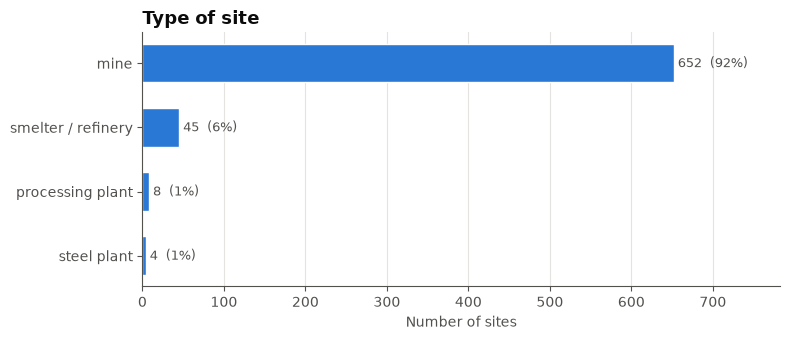

In [21]:
types = sites["asset_main"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(types.index, types.values, color=GROUP_COLOURS["critical mineral"], height=0.6, edgecolor="white")
for y, v in enumerate(types.values):
    ax.text(v + 5, y, f"{v}  ({v / types.sum():.0%})", va="center", fontsize=9, color=TEXT_SOFT)
ax.set_xlim(0, types.max() * 1.2)
ax.set_xlabel("Number of sites")
ax.grid(axis="y", visible=False)
ax.set_title("Type of site")
plt.tight_layout()
plt.savefig(FIG_DIR / "6_site_types.png", dpi=200)
plt.show()

In [22]:
# the same by country (table view)
pd.crosstab(sites["country"], sites["asset_main"], margins=True).sort_values("All", ascending=False)

asset_main,mine,processing plant,smelter / refinery,steel plant,All
country,,,,,
All,652,8,45,4,709
Brazil,163,4,27,2,196
Peru,127,0,2,0,129
Mexico,106,0,1,2,109
Chile,91,3,8,0,102
Bolivia,54,0,0,0,54
Argentina,27,0,2,0,29
Colombia,24,0,0,0,24
Venezuela,16,0,3,0,19


In [23]:
# 10) Summary
#
# - Four countries hold most of the large-scale mining sites: Brazil, Peru, Mexico and Chile (536 of 709 sites).
# - Their profiles differ: Chile is copper, Peru and Mexico are silver, gold, copper and zinc, Brazil is iron ore, gold and other minerals, Bolivia is tin, zinc and silver.
# - Gold sites and critical-mineral sites are often the same sites (many mines produce both).
# - The data is less certain for Bolivia (69 % "Very Low"): check any result about Bolivia with reliable sites only.
# - These are counts of sites, not production, and the list is a 2026 snapshot: it shows where mining is, not how much is produced or how it changed over time.
#
# Files saved in figures/: 1_map_sites.png, 2_sites_per_country.png, 3_gold_vs_critical.png, 4_country_mineral_heatmap.png, 5_confidence_by_country.png, 6_site_types.png.